In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score,recall_score

In [4]:
df = pd.read_csv('Social_Network_Ads.csv')

In [5]:
df


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [6]:
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [7]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [8]:
df['Gender'] = df['Gender'].map({'Male':0,'Female':1})

In [11]:
X = df[['Gender','Age','EstimatedSalary']]
y = df['Purchased']

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state=42)

In [13]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [14]:
clfr = LogisticRegression()
clfr.fit(x_train,y_train)
y_pred = clfr.predict(x_test)

In [16]:
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix : ", cm)

TN, FP,FN,TP = cm.ravel()
accuracy = accuracy_score(y_test,y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)

print("True negative: ",TN)
print("False Positive: ",FP)
print("False negative: ",FN)
print("True positive: ",TP)
print("Accuracy score: ",accuracy)
print("Error rate: ",error_rate)
print("Precision score: ",precision)
print("Recall score: ",precision)

Confusion Matrix :  [[61  2]
 [10 27]]
True negative:  61
False Positive:  2
False negative:  10
True positive:  27
Accuracy score:  0.88
Error rate:  0.12
Precision score:  0.9310344827586207
Recall score:  0.9310344827586207


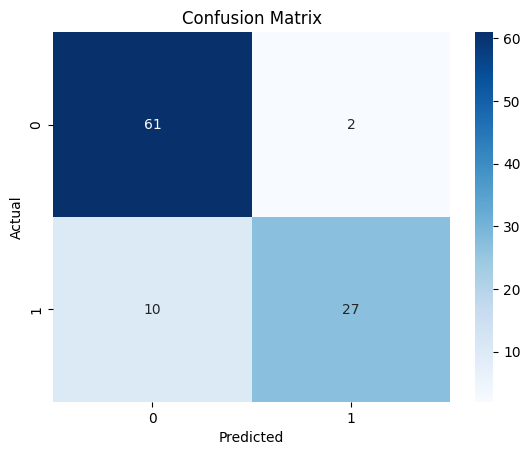

In [22]:
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title('Confusion Matrix')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()